In [1]:
# If you're running on Colab
!pip install datasets bitsandbytes trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 45.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import torch.nn as nn
from accelerate import init_empty_weights
from accelerate.utils.modeling import find_tied_parameters, \
    get_mixed_precision_context_manager
from accelerate.utils.operations import convert_outputs_to_fp32
from bitsandbytes.nn import Linear8bitLt, Linear4bit, LinearFP4, LinearNF4
from collections import Counter
from transformers import AutoModelForCausalLM, BitsAndBytesConfig, AutoTokenizer, AutoConfig
# from transformers.integrations.bitsandbytes import get_keys_to_not_convert
from transformers.quantizers.base import get_keys_to_not_convert
from types import MethodType

import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [3]:
torch.manual_seed(11)
weights = torch.randn(1000) * .07
weights.min(), weights.max()

(tensor(-0.2066), tensor(0.2097))

In [4]:
n_bins = 4
bins = torch.linspace(weights.min(), weights.max(), n_bins+1)
bin_width = bins[1]-bins[0]
bins, bin_width

(tensor([-0.2066, -0.1026,  0.0015,  0.1056,  0.2097]), tensor(0.1041))

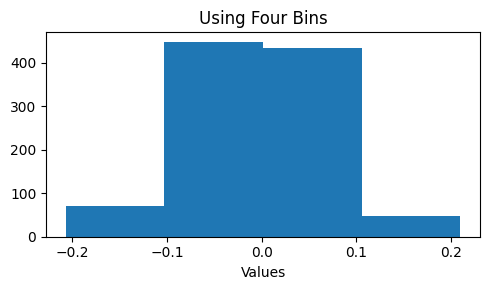

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
counts, _, _ = ax.hist(weights, bins=bins)
ax.set_xlabel('Values')
ax.set_title('Using Four Bins')
fig.tight_layout()

In [6]:
bin_indexes = (weights.view(-1, 1) > bins).to(torch.int).argmin(dim=1) - 1
print(weights[:20])
print(bin_indexes[:20])

tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048,  0.0099, -0.0367,
        -0.0174, -0.0368,  0.2025, -0.0416,  0.0918,  0.0247, -0.0921, -0.0006,
         0.0174,  0.1101, -0.1148, -0.1115])
tensor([1, 2, 1, 2, 1, 0, 2, 1, 1, 1, 3, 1, 2, 2, 1, 1, 2, 3, 0, 0])


In [7]:
bin_values = bins[:-1]
first_bin = bin_values[0]
bin_values

tensor([-0.2066, -0.1026,  0.0015,  0.1056])

In [8]:
torch.arange(0, n_bins) * bin_width + first_bin

tensor([-0.2066, -0.1026,  0.0015,  0.1056])

In [9]:
approx_values = bin_indexes * bin_width + first_bin
print(approx_values[:20]) 

tensor([-0.1026,  0.0015, -0.1026,  0.0015, -0.1026, -0.2066,  0.0015, -0.1026,
        -0.1026, -0.1026,  0.1056, -0.1026,  0.0015,  0.0015, -0.1026, -0.1026,
         0.0015,  0.1056, -0.2066, -0.2066])


In [10]:
print(weights[:20])

tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048,  0.0099, -0.0367,
        -0.0174, -0.0368,  0.2025, -0.0416,  0.0918,  0.0247, -0.0921, -0.0006,
         0.0174,  0.1101, -0.1148, -0.1115])


In [11]:
mse_fn = nn.MSELoss()
mse_fn(approx_values, weights).sqrt()

tensor(0.0615)

In [12]:
def quantize(weights, n_bits=8):
    assert n_bits <= 16, "Using more bits may result in slow execution and/or crashing."
    n_bins = 2**n_bits
    bins = torch.linspace(weights.min(), weights.max(), n_bins+1)
    first_bin = bins[0]
    bin_width = bins[1]-bins[0]
    bin_indexes = ((weights.view(-1, 1) > bins).to(torch.int).argmin(dim=1) * 1)
    return bin_indexes, bin_width, first_bin


def dequantize(bin_indexes, bin_width, first_bin):
    approx_values = bin_indexes * bin_width + first_bin
    return approx_values 

In [13]:
for n_bits in [2, 4, 8, 16]:
    res = quantize(weights, n_bits=n_bits)
    approx_values = dequantize(*res)
    print(f'{n_bits}-bit Quantization:')
    print(approx_values[:6])
    print(weights[:6])
    print(mse_fn(approx_values, weights).sqrt()) 

2-bit Quantization:
tensor([ 0.0015,  0.1056,  0.0015,  0.1056,  0.0015, -0.1026])
tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048])
tensor(0.0591)
4-bit Quantization:
tensor([-0.0245,  0.0796, -0.0245,  0.0275,  0.0015, -0.1026])
tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048])
tensor(0.0146)
8-bit Quantization:
tensor([-0.0343,  0.0731, -0.0245,  0.0096, -0.0115, -0.1042])
tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048])
tensor(0.0009)
16-bit Quantization:
tensor([-0.0359,  0.0718, -0.0248,  0.0085, -0.0128, -0.1049])
tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048])
tensor(0.0001)


In [14]:
fp16_weights = weights.to(torch.float16)
print(fp16_weights[:6])
print(weights[:6]) 

tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048],
       dtype=torch.float16)
tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048])


In [15]:
print(mse_fn(fp16_weights, weights).sqrt())

tensor(1.4244e-05)


In [16]:
torch.manual_seed(14)
tiny_values = torch.randn(1000)*1e-5
fp16_tiny_values = tiny_values.to(torch.float16)
mse_fn(fp16_tiny_values, tiny_values)

tensor(2.8526e-16)

In [17]:
print(tiny_values[155:160])
print(fp16_tiny_values[155:160])

tensor([-2.7241e-06,  1.1441e-05,  3.7199e-06, -1.1252e-06, -2.4735e-08])
tensor([-2.7418e-06,  1.1444e-05,  3.6955e-06, -1.1325e-06, -0.0000e+00],
       dtype=torch.float16)


In [18]:
torch.manual_seed(19)
large_values = torch.randn(1000)*1e5
fp16_large_values = large_values.to(torch.float16)
print(large_values[:5])
print(fp16_large_values[:5])

tensor([155074.0938,  64881.6602,   2729.5815, -40790.6562,  68846.7188])
tensor([    inf,  64896.,   2730., -40800.,     inf], dtype=torch.float16)


In [19]:
fp16_info = torch.finfo(torch.float16)
fp16_info

finfo(resolution=0.001, min=-65504, max=65504, eps=0.000976562, smallest_normal=6.10352e-05, tiny=6.10352e-05, dtype=float16)

In [21]:
smallest_subnormal = fp16_info.smallest_normal * 2**-10
smallest_subnormal 

5.960464477539063e-08

In [22]:
bf16_info = torch.finfo(torch.bfloat16)
print(bf16_info)
print(fp16_info) 

finfo(resolution=0.01, min=-3.38953e+38, max=3.38953e+38, eps=0.0078125, smallest_normal=1.17549e-38, tiny=1.17549e-38, dtype=bfloat16)
finfo(resolution=0.001, min=-65504, max=65504, eps=0.000976562, smallest_normal=6.10352e-05, tiny=6.10352e-05, dtype=float16)


In [23]:
fp32_info = torch.finfo(torch.float32)
fp32_info

finfo(resolution=1e-06, min=-3.40282e+38, max=3.40282e+38, eps=1.19209e-07, smallest_normal=1.17549e-38, tiny=1.17549e-38, dtype=float32)

In [24]:
x = torch.tensor([0.555555555])
torch.set_printoptions(precision=9)
print(x)
print(x.to(torch.float16))
print(x.to(torch.bfloat16))
torch.set_printoptions(precision=4)

tensor([0.555555582])
tensor([0.555664062], dtype=torch.float16)
tensor([0.554687500], dtype=torch.bfloat16)


#### Loading Models

In [ ]:
def get_parm_dtypes(iterable, top_k=3):
    return Counter([p.dtype for p in iterable]).most_common(top_k)


def select_inference_device():
    """Use CUDA only when this PyTorch build contains kernels for the GPU."""
    if not torch.cuda.is_available():
        print("CUDA is not available; using CPU.")
        return "cpu"

    major, minor = torch.cuda.get_device_capability(0)
    device_arch = f"sm_{major}{minor}"
    compiled_arches = set(torch.cuda.get_arch_list())
    if device_arch not in compiled_arches:
        print(
            f"{torch.cuda.get_device_name(0)} requires {device_arch}, but "
            f"PyTorch {getattr(torch, '__version__', 'unknown')} was compiled for "
            f"{sorted(compiled_arches)}. Using CPU to avoid "
            "cudaErrorNoKernelImageForDevice."
        )
        return "cpu"

    return "cuda:0"


model_id = "facebook/opt-350m"
inference_device = select_inference_device()
print(f"Inference device: {inference_device}")

# With no dtype override, Transformers follows the checkpoint config, which is FP16.
model = AutoModelForCausalLM.from_pretrained(
    model_id, device_map=inference_device
)
print(model.get_memory_footprint() / 1e6, get_parm_dtypes(model.parameters()))

In [ ]:
# Release the FP16 demonstration model before loading a second copy.
del model
if inference_device.startswith("cuda"):
    torch.cuda.empty_cache()

# Override the checkpoint's FP16 metadata and load every floating-point weight as FP32.
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float32,
    device_map=inference_device,
)
assert model.dtype == torch.float32
print(f"Loaded {model_id} on {model.device} with dtype {model.dtype}")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_id)
batch = tokenizer(["This is a simple test"], return_tensors="pt").to(model.device)
batch["labels"] = batch["input_ids"].clone()

model.eval()
with torch.inference_mode():
    out = model(**batch)

out.loss